In [28]:

!pip install datasets transformers torch accelerate


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [29]:
from datasets import load_dataset
dataset_train = load_dataset(
    "keremberke/shoe-classification",
    'default', 
    revision="refs/convert/parquet"
)

dataset_train = dataset_train['train']

In [30]:
#사전학습 Vision 트랜스포머 불러오기
from transformers import ViTImageProcessor, ViTForImageClassification
from sklearn.neighbors import NearestNeighbors
import torch
import matplotlib.pyplot as plt

# import model - https://huggingface.co/google/vit-base-patch16-224-in21k
model_id = 'google/vit-base-patch16-224-in21k'

model_vanilla = ViTForImageClassification.from_pretrained(model_id)
feature_extractor_vanilla = ViTImageProcessor.from_pretrained(model_id)

Loading weights: 100%|██████████| 198/198 [00:00<00:00, 1295.31it/s, Materializing param=vit.layernorm.weight]                                 
ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                 | Status     | 
--------------------+------------+-
pooler.dense.bias   | UNEXPECTED | 
pooler.dense.weight | UNEXPECTED | 
classifier.weight   | MISSING    | 
classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [31]:
model_vanilla

ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (intermed

In [32]:
feature_extractor_vanilla

ViTImageProcessor {
  "do_convert_rgb": null,
  "do_normalize": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.5,
    0.5,
    0.5
  ],
  "image_processor_type": "ViTImageProcessor",
  "image_std": [
    0.5,
    0.5,
    0.5
  ],
  "resample": 2,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "height": 224,
    "width": 224
  }
}

In [33]:
model_vanilla.classifier = torch.nn.Identity()

In [34]:

def extract_embeddings(dataset, model, feature_extractor):
    model.eval()
    embeddings = []
    with torch.no_grad():
        for item in dataset:
            inputs = feature_extractor(images=item['image'], return_tensors="pt")
            outputs = model(**inputs)
            embeddings.append(outputs.logits.squeeze().numpy())
    return embeddings

In [35]:

def retrieve_images(index, nn_model, dataset, embeddings):
    index = int(index)
    distances, indices = nn_model.kneighbors([embeddings[index]])

    indexed_distances = [(int(i), dist) for i, dist in zip(indices[0], distances[0]) if i != index]

    indexed_distances.sort(key=lambda x: x[1])

    retrieved_images = [dataset[idx]["image"] for idx, _ in indexed_distances]
    return retrieved_images

def show_images(dataset, num_images=5):
    fig, axes = plt.subplots(1, num_images, figsize=(15, 3))
    for i in range(num_images):
        img = dataset["train"][i]["image"]
        axes[i].imshow(img)
        axes[i].axis('off')
    plt.show()

In [36]:
embeddings_vanilla = extract_embeddings(dataset_train, model_vanilla, feature_extractor_vanilla)
nn_model_vanilla = NearestNeighbors(n_neighbors=6, algorithm='ball_tree')
nn_model_vanilla.fit(embeddings_vanilla)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",6
,"radius radius: float, default=1.0Range of parameter space to use by default for :meth:`radius_neighbors`queries.",1.0
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'ball_tree'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"p p: float (positive), default=2Parameter for the Minkowski metric fromsklearn.metrics.pairwise.pairwise_distances. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


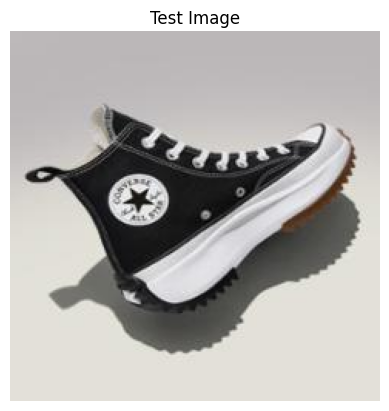

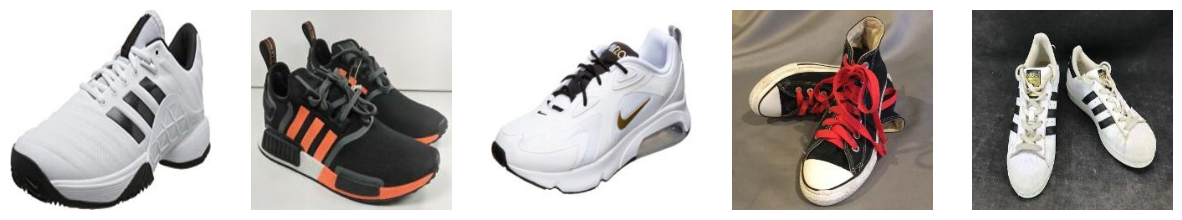

In [37]:

import matplotlib.pyplot as plt
test_index =358
retrieved_images = retrieve_images(test_index, nn_model_vanilla, dataset_train, embeddings_vanilla)

plt.imshow(dataset_train[test_index]["image"])
plt.title("Test Image")
plt.axis('off')
plt.show()

show_images({"train": [{"image": img} for img in retrieved_images]})

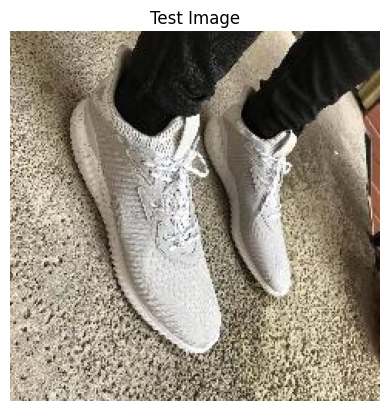

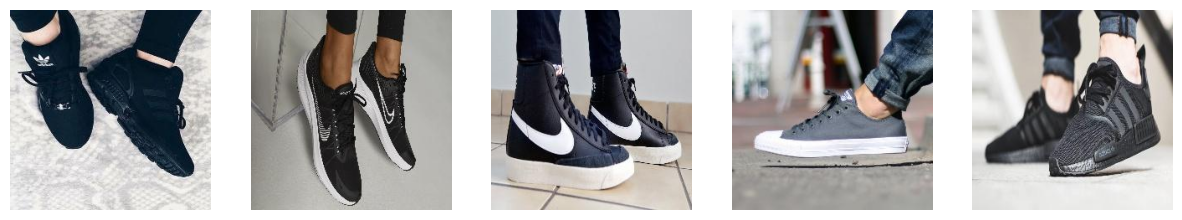

In [38]:

test_index = 65
retrieved_images = retrieve_images(test_index, nn_model_vanilla, dataset_train, embeddings_vanilla)

plt.imshow(dataset_train[test_index]["image"])
plt.title("Test Image")
plt.axis('off')
plt.show()

show_images({"train": [{"image": img} for img in retrieved_images]})

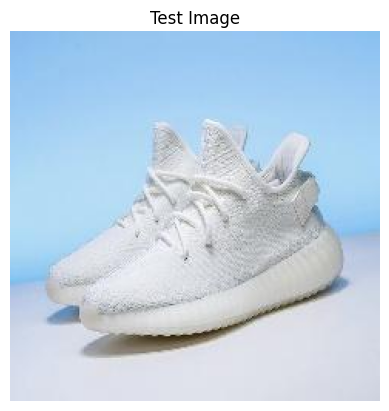

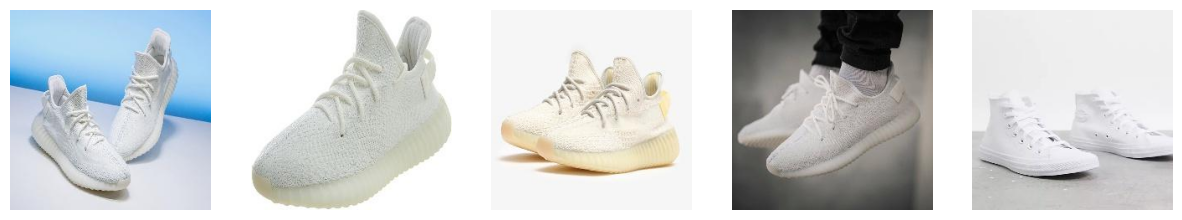

In [39]:

test_index = 94
retrieved_images = retrieve_images(test_index, nn_model_vanilla, dataset_train, embeddings_vanilla)

plt.imshow(dataset_train[test_index]["image"])
plt.title("Test Image")
plt.axis('off')
plt.show()

show_images({"train": [{"image": img} for img in retrieved_images]})

In [40]:
#Fine-Tuning
# dataset_test = load_dataset("keremberke/shoe-classification",'full', split='validation')

from datasets import load_dataset
dataset_test = load_dataset(
    "keremberke/shoe-classification",
    'default', 
    split='validation',
    revision="refs/convert/parquet"
)

In [41]:

def preprocess(batch):
    inputs = feature_extractor_vanilla(
        batch['image'],
        return_tensors='pt'
    )
    inputs['labels'] = batch['labels']
    return inputs

In [42]:

train_prepared = dataset_train.with_transform(preprocess)
test_prepared = dataset_test.with_transform(preprocess)

In [43]:

def collate_batch(batch):
    pixel_vals = [item['pixel_values'] for item in batch]
    labels = [item['labels'] for item in batch]
    return {'pixel_values': torch.stack(pixel_vals), 'labels': torch.tensor(labels)}

In [44]:
!pip install evaluate


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [45]:
import numpy as np

def evaluate_model_performance(outputs):
    predicted_labels = np.argmax(outputs.predictions, axis=1)
    true_labels = outputs.label_ids
    accuracy = (predicted_labels == true_labels).mean()
    return {"accuracy": float(accuracy)}

In [46]:

num_labels_in_dataset = len(set(dataset_train['labels']))
label_names = dataset_train.features['labels'].names

num_labels_in_dataset, label_names

(3, ['converse', 'adidas', 'nike'])

In [47]:
model = ViTForImageClassification.from_pretrained(
    model_id,
    num_labels=num_labels_in_dataset
)

Loading weights: 100%|██████████| 198/198 [00:00<00:00, 1878.04it/s, Materializing param=vit.layernorm.weight]                                 
ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                 | Status     | 
--------------------+------------+-
pooler.dense.bias   | UNEXPECTED | 
pooler.dense.weight | UNEXPECTED | 
classifier.weight   | MISSING    | 
classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [48]:
model

ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (intermed

In [49]:

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

In [50]:

import transformers
from transformers import TrainingArguments

training_args = TrainingArguments(
  output_dir="./shoe",
  per_device_train_batch_size=16,
  eval_strategy="steps",
  num_train_epochs=10,
  save_steps=20,
  eval_steps=20,
  logging_steps=20,
  learning_rate=0.0002,
  save_total_limit=2,
  remove_unused_columns=False,
  push_to_hub=False,
  #load_best_model_at_end=True,
)

In [51]:
model.to(device)

ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (intermed

In [52]:

from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    data_collator=collate_batch,
    compute_metrics=evaluate_model_performance,
    train_dataset=train_prepared,
    eval_dataset=test_prepared,
    processing_class=feature_extractor_vanilla,
)

In [53]:

training_outcome = trainer.train()
trainer.save_model()

training_metrics = training_outcome.metrics
trainer.log_metrics("training", training_metrics)
trainer.save_metrics("training", training_metrics)

trainer.save_state()

/Users/igyeongseob/Develop/ai/RAG/vectorDB/vector/venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss,Validation Loss,Accuracy
20,0.793612,1.702924,0.000000
40,0.573391,1.115188,0.261905
60,0.243890,0.614467,0.797619
80,0.191833,0.672224,0.779762
100,0.065086,0.725955,0.797619
120,0.042231,1.207736,0.660714
140,0.029336,0.326863,0.910714
160,0.013543,1.439549,0.636905
180,0.010937,1.267045,0.654762
200,0.009411,0.850602,0.791667


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.10it/s]
/Users/igyeongseob/Develop/ai/RAG/vectorDB/vector/venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.30it/s]
/Users/igyeongseob/Develop/ai/RAG/vectorDB/vector/venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  5.15it/s]
/Users/igyeongseob/Develop/ai/RAG/vectorDB/vector/venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Writing

***** training metrics *****
  epoch                    =        10.0
  total_flos               = 417146565GF
  train_loss               =      0.1096
  train_runtime            =  0:05:58.77
  train_samples_per_second =       16.11
  train_steps_per_second   =       1.031


In [54]:

evaluation_metrics = trainer.evaluate(test_prepared)

trainer.log_metrics("evaluation", evaluation_metrics)
trainer.save_metrics("evaluation", evaluation_metrics)

/Users/igyeongseob/Develop/ai/RAG/vectorDB/vector/venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


***** evaluation metrics *****
  epoch                   =       10.0
  eval_accuracy           =     0.7738
  eval_loss               =     1.0049
  eval_runtime            = 0:00:02.64
  eval_samples_per_second =     63.607
  eval_steps_per_second   =      7.951


In [55]:

fine_tuned_path = './shoe'
model_finetuned = ViTForImageClassification.from_pretrained(fine_tuned_path)
feature_extractor_finetuned = ViTImageProcessor.from_pretrained(fine_tuned_path)
model_finetuned.classifier = torch.nn.Identity()

embeddings_ft = extract_embeddings(dataset_train, model_finetuned, feature_extractor_finetuned)

nn_model_ft = NearestNeighbors(n_neighbors=6, algorithm='ball_tree')
nn_model_ft.fit(embeddings_ft)

Loading weights: 100%|██████████| 200/200 [00:00<00:00, 1794.83it/s, Materializing param=vit.layernorm.weight]                                 


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",6
,"radius radius: float, default=1.0Range of parameter space to use by default for :meth:`radius_neighbors`queries.",1.0
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'ball_tree'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"p p: float (positive), default=2Parameter for the Minkowski metric fromsklearn.metrics.pairwise.pairwise_distances. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


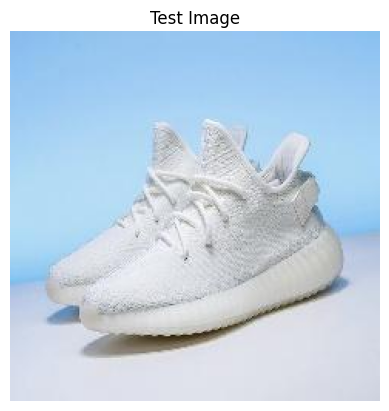

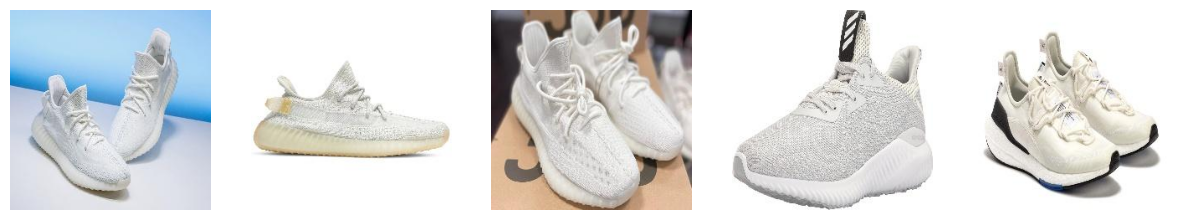

In [56]:
import matplotlib.pyplot as plt
test_index = 94
retrieved_images = retrieve_images(test_index, nn_model_ft, dataset_train,embeddings_ft)
plt.imshow(dataset_train[test_index]["image"])
plt.title("Test Image")
plt.axis('off')
plt.show()

show_images({"train": [{"image": img} for img in retrieved_images]})

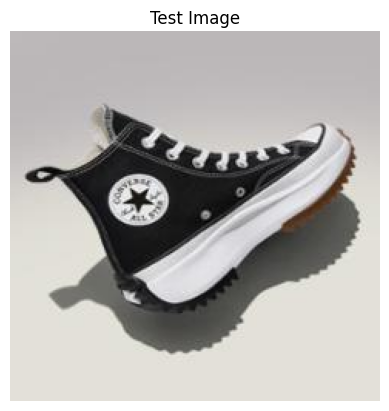

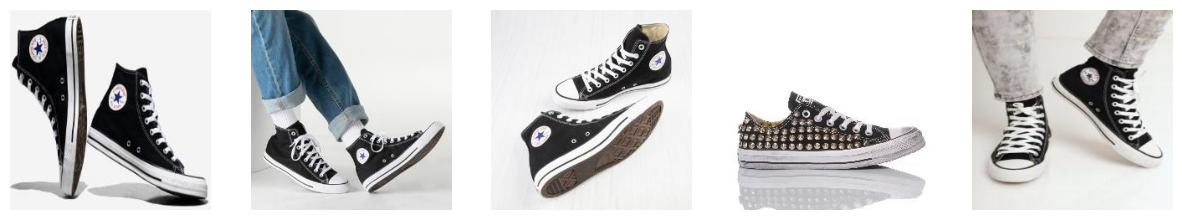

In [57]:
test_index = 358
retrieved_images = retrieve_images(test_index, nn_model_ft, dataset_train,embeddings_ft)
plt.imshow(dataset_train[test_index]["image"])
plt.title("Test Image")
plt.axis('off')
plt.show()

show_images({"train": [{"image": img} for img in retrieved_images]})

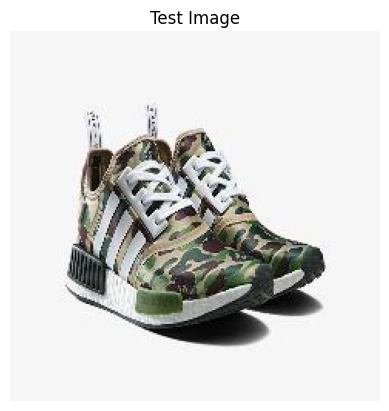

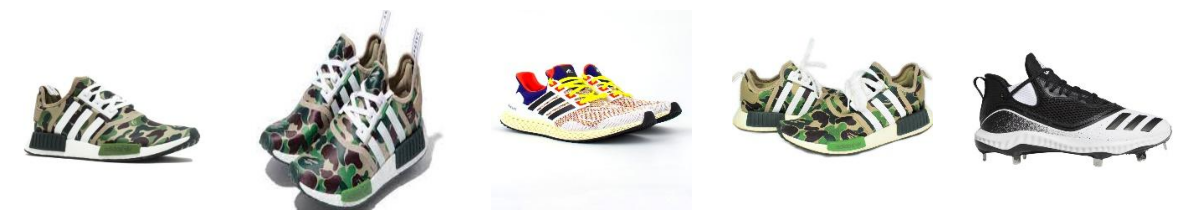

In [58]:
test_index = 174
retrieved_images = retrieve_images(test_index, nn_model_ft, dataset_train,embeddings_ft)
plt.imshow(dataset_train[test_index]["image"])
plt.title("Test Image")
plt.axis('off')
plt.show()

show_images({"train": [{"image": img} for img in retrieved_images]})

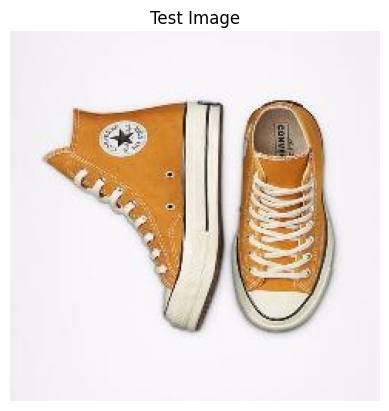

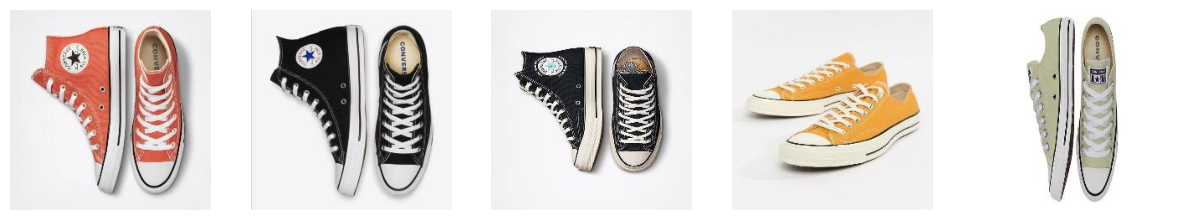

In [59]:
test_index =383
retrieved_images = retrieve_images(test_index, nn_model_ft, dataset_train,embeddings_ft)
plt.imshow(dataset_train[test_index]["image"])
plt.title("Test Image")
plt.axis('off')
plt.show()

show_images({"train": [{"image": img} for img in retrieved_images]})

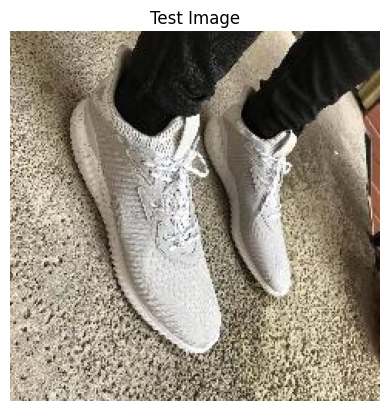

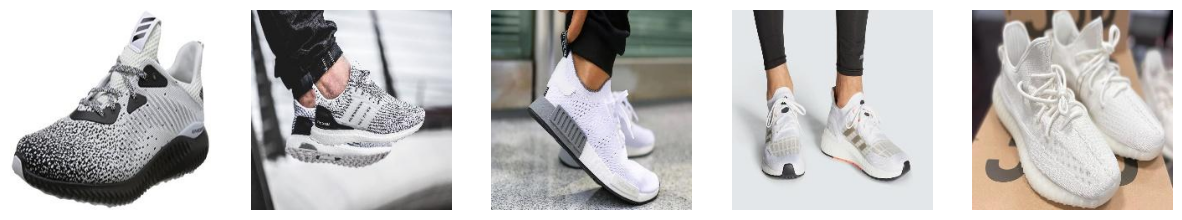

In [60]:
test_index = 65
retrieved_images = retrieve_images(test_index, nn_model_ft, dataset_train,embeddings_ft)
plt.imshow(dataset_train[test_index]["image"])
plt.title("Test Image")
plt.axis('off')
plt.show()

show_images({"train": [{"image": img} for img in retrieved_images]})